In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
matches = pd.read_csv('/content/ipl_matches_data.csv')
deliveries = pd.read_csv('/content/ball_by_ball_data.csv')
teams = pd.read_csv('/content/teams_data.csv')
team_aliases = pd.read_csv('/content/team_aliases.csv')
players = pd.read_csv('/content/players-data-updated.csv')

print("✅ All files loaded!")
print("Matches:", matches.shape)
print("Deliveries:", deliveries.shape)
print("Teams:", teams.shape)
print("Team Aliases:", team_aliases.shape)
print("Players:", players.shape)

✅ All files loaded!
Matches: (1212, 23)
Deliveries: (288226, 30)
Teams: (16, 2)
Team Aliases: (46, 3)
Players: (799, 6)


In [3]:
print("=" * 50)
print("MATCHES — RAW OVERVIEW")
print("=" * 50)
print("Shape:", matches.shape)
print("\nColumns:", matches.columns.tolist())
print("\nData Types:\n", matches.dtypes)
print("\nFirst 3 rows:\n", matches.head(3))
print("\nNull Values:\n", matches.isnull().sum())

MATCHES — RAW OVERVIEW
Shape: (1212, 23)

Columns: ['match_id', 'season_id', 'balls_per_over', 'city', 'match_date', 'event_name', 'match_number', 'gender', 'match_type', 'format', 'overs', 'season', 'team_type', 'venue', 'toss_winner', 'team1', 'team2', 'toss_decision', 'match_winner', 'win_by_runs', 'win_by_wickets', 'result', 'player_of_match']

Data Types:
 match_id             int64
season_id            int64
balls_per_over       int64
city                object
match_date          object
event_name          object
match_number       float64
gender              object
match_type          object
format              object
overs                int64
season              object
team_type           object
venue               object
toss_winner          int64
team1                int64
team2                int64
toss_decision       object
match_winner         int64
win_by_runs        float64
win_by_wickets     float64
result              object
player_of_match    float64
dtype: object



In [4]:
print("=" * 50)
print("DELIVERIES — RAW OVERVIEW")
print("=" * 50)
print("Shape:", deliveries.shape)
print("\nColumns:", deliveries.columns.tolist())
print("\nData Types:\n", deliveries.dtypes)
print("\nFirst 3 rows:\n", deliveries.head(3))
print("\nNull Values:\n", deliveries.isnull().sum())

DELIVERIES — RAW OVERVIEW
Shape: (288226, 30)

Columns: ['season_id', 'match_id', 'batter', 'bowler', 'non_striker', 'team_batting', 'team_bowling', 'over_number', 'ball_number', 'batter_runs', 'extras', 'total_runs', 'batsman_type', 'bowler_type', 'player_out', 'fielders_involved', 'is_wicket', 'is_wide_ball', 'is_no_ball', 'is_leg_bye', 'is_bye', 'is_penalty', 'wide_ball_runs', 'no_ball_runs', 'leg_bye_runs', 'bye_runs', 'penalty_runs', 'wicket_kind', 'is_super_over', 'innings']

Data Types:
 season_id             int64
match_id              int64
batter               object
bowler               object
non_striker          object
team_batting          int64
team_bowling          int64
over_number           int64
ball_number           int64
batter_runs           int64
extras                int64
total_runs            int64
batsman_type         object
bowler_type          object
player_out           object
fielders_involved    object
is_wicket              bool
is_wide_ball           b

In [5]:
print("=" * 50)
print("TEAMS")
print("=" * 50)
print(teams)

print("\n" + "=" * 50)
print("TEAM ALIASES (first 10)")
print("=" * 50)
print(team_aliases.head(10))

print("\n" + "=" * 50)
print("PLAYERS (first 5)")
print("=" * 50)
print(players.head())

TEAMS
    team_id                    team_name
0         1  Royal Challengers Bangalore
1         2          Sunrisers Hyderabad
2         3               Mumbai Indians
3         4       Rising Pune Supergiant
4         5                Gujarat Lions
5         6        Kolkata Knight Riders
6       129          Chennai Super Kings
7       134             Rajasthan Royals
8       252               Delhi Capitals
9       494                 Punjab Kings
10      614         Lucknow Super Giants
11      615               Gujarat Titans
12     1068              Deccan Chargers
13     1414         Kochi Tuskers Kerala
14     1419                Pune Warriors
15     3604      Rising Pune Supergiants

TEAM ALIASES (first 10)
   alias_id  team_id                   alias_name
0         1        1                          RCB
1         2        1  Royal Challengers Bengaluru
2         3      252             Delhi Daredevils
3         4      494              Kings XI Punjab
4         5        1  

In [6]:
# Build team_id → team_name mapping
team_map = dict(zip(teams['team_id'], teams['team_name']))

# Build alias_id → team_id mapping
alias_map = dict(zip(team_aliases['alias_id'], team_aliases['team_id']))

def decode_team(tid):
    if tid in team_map:
        return team_map[tid]
    elif tid in alias_map:
        return team_map.get(alias_map[tid], f"Unknown({tid})")
    else:
        return f"Unknown({tid})"

# Apply to matches
matches['team1_name'] = matches['team1'].apply(decode_team)
matches['team2_name'] = matches['team2'].apply(decode_team)
matches['toss_winner_name'] = matches['toss_winner'].apply(decode_team)
matches['match_winner_name'] = matches['match_winner'].apply(decode_team)

print("✅ Team names decoded!")
print(matches[['team1_name','team2_name','toss_winner_name','match_winner_name']].head(3))

✅ Team names decoded!
                    team1_name                   team2_name  \
0  Royal Challengers Bangalore        Kolkata Knight Riders   
1          Sunrisers Hyderabad  Royal Challengers Bangalore   
2       Rising Pune Supergiant               Mumbai Indians   

              toss_winner_name       match_winner_name  
0  Royal Challengers Bangalore   Kolkata Knight Riders  
1  Royal Challengers Bangalore     Sunrisers Hyderabad  
2       Rising Pune Supergiant  Rising Pune Supergiant  


In [7]:
player_map = dict(zip(players['player_id'], players['player_name']))
matches['player_of_match_name'] = matches['player_of_match'].map(player_map)

print("✅ Player names decoded!")
print(matches[['player_of_match','player_of_match_name']].head(5))

✅ Player names decoded!
   player_of_match player_of_match_name
0             46.0          BB McCullum
1             15.0         Yuvraj Singh
2             36.0            SPD Smith
3             57.0              CA Lynn
4             71.0           GJ Maxwell


In [8]:
# Teams that changed names over the years
rename_map = {
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Deccan Chargers': 'Sunrisers Hyderabad'
}

for col in ['team1_name','team2_name','toss_winner_name','match_winner_name']:
    matches[col] = matches[col].replace(rename_map)

print("✅ Team names standardized!")
print(matches['match_winner_name'].unique())

✅ Team names standardized!
['Kolkata Knight Riders' 'Sunrisers Hyderabad' 'Rising Pune Supergiants'
 'Punjab Kings' 'Royal Challengers Bengaluru' 'Mumbai Indians'
 'Delhi Capitals' 'Gujarat Lions' 'Chennai Super Kings' 'Rajasthan Royals'
 'Gujarat Titans' 'Lucknow Super Giants' 'Pune Warriors'
 'Kochi Tuskers Kerala']


In [9]:
# Fix date
matches['match_date'] = pd.to_datetime(matches['match_date'])

# win_by_runs and win_by_wickets nulls are natural
# (won by wickets = no win_by_runs value and vice versa) — leave them

# Fill remaining nulls
matches['city'] = matches['city'].fillna(
    matches['venue'].str.split(',').str[0])
matches['match_number'] = matches['match_number'].fillna('Playoff')
matches['player_of_match_name'] = matches['player_of_match_name'].fillna('Unknown')
matches['match_winner_name'] = matches['match_winner_name'].fillna('No Result')

# Remove duplicates
matches.drop_duplicates(inplace=True)

print("✅ Nulls handled & duplicates removed!")
print("\nRemaining nulls:")
print(matches.isnull().sum())
print("\nFinal shape:", matches.shape)

✅ Nulls handled & duplicates removed!

Remaining nulls:
match_id                  0
season_id                 0
balls_per_over            0
city                      0
match_date                0
event_name                0
match_number              0
gender                    0
match_type                0
format                    0
overs                     0
season                    0
team_type                 0
venue                     0
toss_winner               0
team1                     0
team2                     0
toss_decision             0
match_winner              0
win_by_runs             666
win_by_wickets          571
result                    0
player_of_match           9
team1_name                0
team2_name                0
toss_winner_name          0
match_winner_name         0
player_of_match_name      0
dtype: int64

Final shape: (1212, 28)


In [10]:
# Decode team IDs in deliveries
deliveries['team_batting_name'] = deliveries['team_batting'].apply(decode_team)
deliveries['team_bowling_name'] = deliveries['team_bowling'].apply(decode_team)

# Standardize
for col in ['team_batting_name','team_bowling_name']:
    deliveries[col] = deliveries[col].replace(rename_map)

# player_out, fielders_involved, wicket_kind nulls are natural
# (they are only filled when a wicket falls) — leave them

# Remove duplicates
deliveries.drop_duplicates(inplace=True)

print("✅ Deliveries cleaned!")
print("Final shape:", deliveries.shape)
print(deliveries[['batter','bowler','team_batting_name','team_bowling_name']].head(3))

✅ Deliveries cleaned!
Final shape: (288226, 32)
        batter   bowler      team_batting_name            team_bowling_name
0   SC Ganguly  P Kumar  Kolkata Knight Riders  Royal Challengers Bengaluru
1  BB McCullum  P Kumar  Kolkata Knight Riders  Royal Challengers Bengaluru
2  BB McCullum  P Kumar  Kolkata Knight Riders  Royal Challengers Bengaluru


In [11]:
print("=" * 50)
print("CLEANED DATA SUMMARY")
print("=" * 50)
print(f"Matches     : {matches.shape[0]} rows, {matches.shape[1]} columns")
print(f"Deliveries  : {deliveries.shape[0]} rows, {deliveries.shape[1]} columns")
print(f"\nSample match winner names : {matches['match_winner_name'].unique()[:5]}")
print(f"Sample batter names       : {deliveries['batter'].unique()[:5]}")
print(f"\nDate range : {matches['match_date'].min()} to {matches['match_date'].max()}")

CLEANED DATA SUMMARY
Matches     : 1212 rows, 28 columns
Deliveries  : 288226 rows, 32 columns

Sample match winner names : ['Kolkata Knight Riders' 'Sunrisers Hyderabad' 'Rising Pune Supergiants'
 'Punjab Kings' 'Royal Challengers Bengaluru']
Sample batter names       : ['SC Ganguly' 'BB McCullum' 'RT Ponting' 'DJ Hussey' 'Mohammad Hafeez']

Date range : 2008-04-18 00:00:00 to 2026-05-01 00:00:00


In [12]:
print("\n" + "="*60)
print(" Exploratory Data Analysis")
print("="*60 + "\n")


 Exploratory Data Analysis



In [13]:
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
print("✅ Plot settings done!")

✅ Plot settings done!


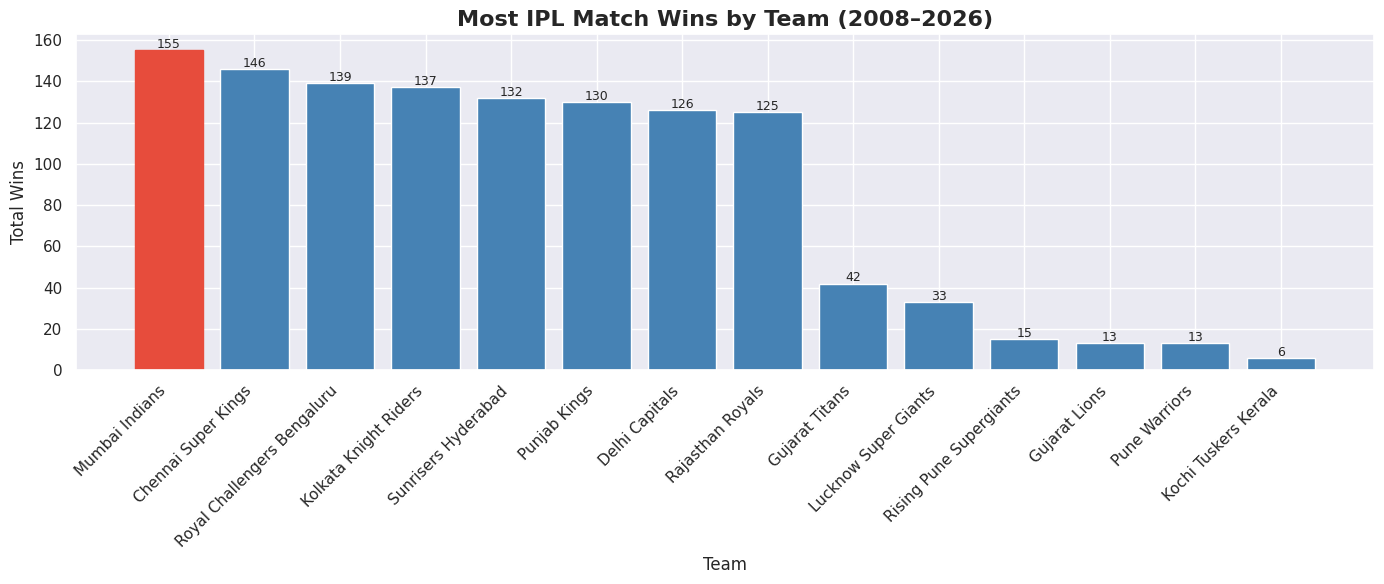


🏆 Top 3 teams:
match_winner_name
Mumbai Indians                 155
Chennai Super Kings            146
Royal Challengers Bengaluru    139
Name: count, dtype: int64


In [14]:
win_counts = (matches[matches['match_winner_name'] != 'No Result']
              ['match_winner_name'].value_counts())

plt.figure(figsize=(14,6))
bars = plt.bar(win_counts.index, win_counts.values,
               color='steelblue', edgecolor='white')
bars[0].set_color('#e74c3c')  # highlight top team

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             str(int(bar.get_height())),
             ha='center', fontsize=9)

plt.title('Most IPL Match Wins by Team (2008–2026)', fontsize=16, fontweight='bold')
plt.xlabel('Team')
plt.ylabel('Total Wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('team_wins.png', dpi=150)
plt.show()

print("\n🏆 Top 3 teams:")
print(win_counts.head(3))

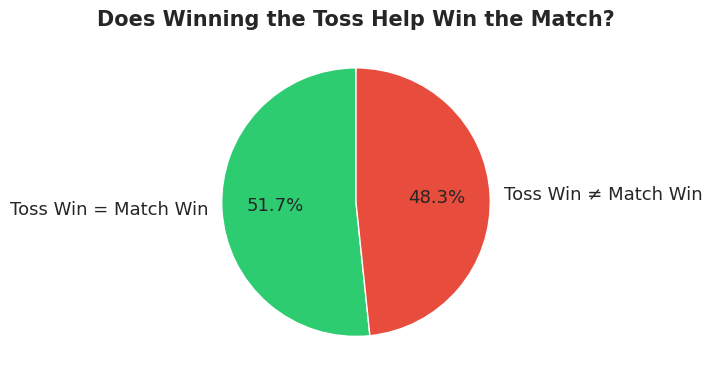


💡 Toss winners go on to win 51.7% of matches


In [15]:
valid = matches[matches['match_winner_name'] != 'No Result'].copy()
valid['toss_helped'] = valid['toss_winner_name'] == valid['match_winner_name']
toss_pct = valid['toss_helped'].value_counts(normalize=True) * 100

plt.figure(figsize=(7,7))
plt.pie(toss_pct.values,
        labels=['Toss Win = Match Win', 'Toss Win ≠ Match Win'],
        autopct='%1.1f%%',
        colors=['#2ecc71','#e74c3c'],
        startangle=90,
        textprops={'fontsize':13})
plt.title('Does Winning the Toss Help Win the Match?',
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('toss_impact.png', dpi=150)
plt.show()

print(f"\n💡 Toss winners go on to win {toss_pct[True]:.1f}% of matches")

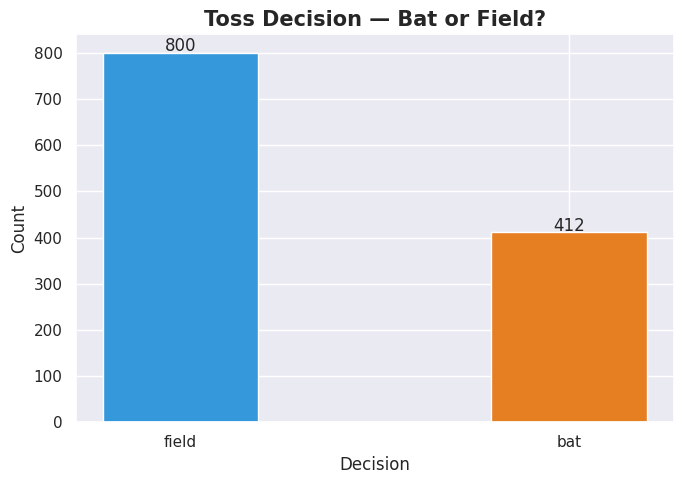

In [16]:
toss_dec = matches['toss_decision'].value_counts()

plt.figure(figsize=(7,5))
bars = plt.bar(toss_dec.index, toss_dec.values,
               color=['#3498db','#e67e22'],
               edgecolor='white', width=0.4)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 3,
             str(int(bar.get_height())),
             ha='center', fontsize=12)

plt.title('Toss Decision — Bat or Field?', fontsize=15, fontweight='bold')
plt.xlabel('Decision')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('toss_decision.png', dpi=150)
plt.show()

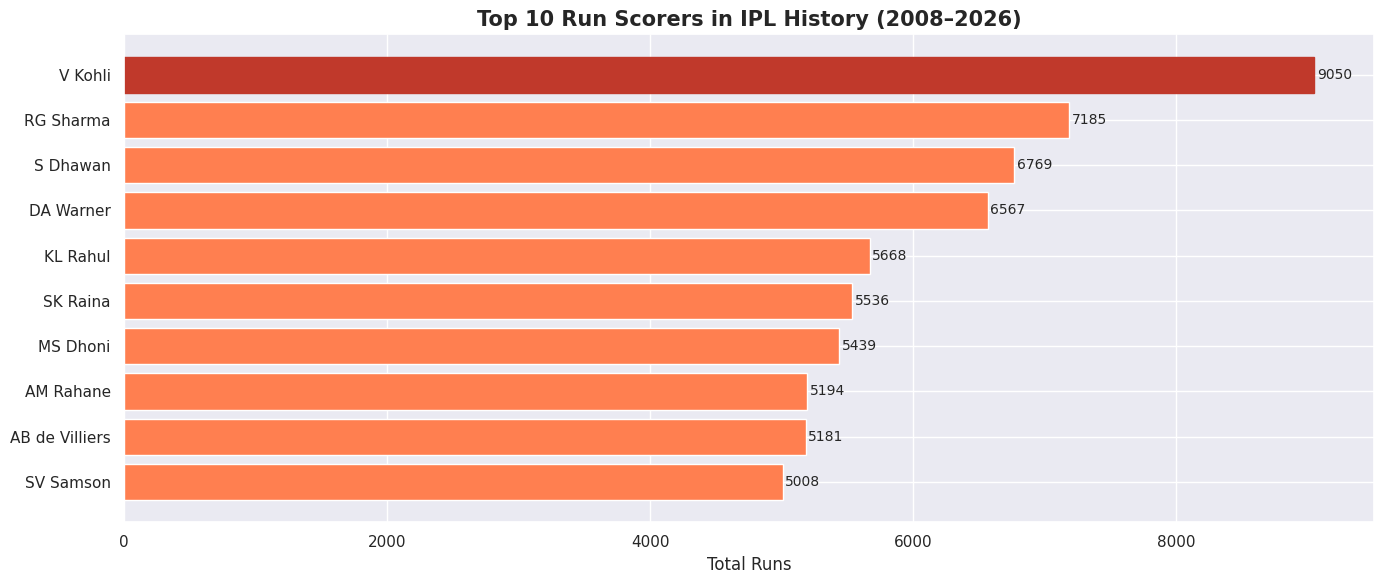


🏏 All-time top scorer: V Kohli — 9050 runs


In [17]:
top_batters = (deliveries.groupby('batter')['batter_runs']
               .sum()
               .sort_values(ascending=False)
               .head(10))

plt.figure(figsize=(14,6))
bars = plt.barh(top_batters.index[::-1], top_batters.values[::-1],
                color='coral', edgecolor='white')
bars[-1].set_color('#c0392b')

for bar in bars:
    plt.text(bar.get_width() + 20,
             bar.get_y() + bar.get_height()/2,
             str(int(bar.get_width())),
             va='center', fontsize=10)

plt.title('Top 10 Run Scorers in IPL History (2008–2026)',
          fontsize=15, fontweight='bold')
plt.xlabel('Total Runs')
plt.tight_layout()
plt.savefig('top_batters.png', dpi=150)
plt.show()

print(f"\n🏏 All-time top scorer: {top_batters.index[0]} — {top_batters.values[0]} runs")

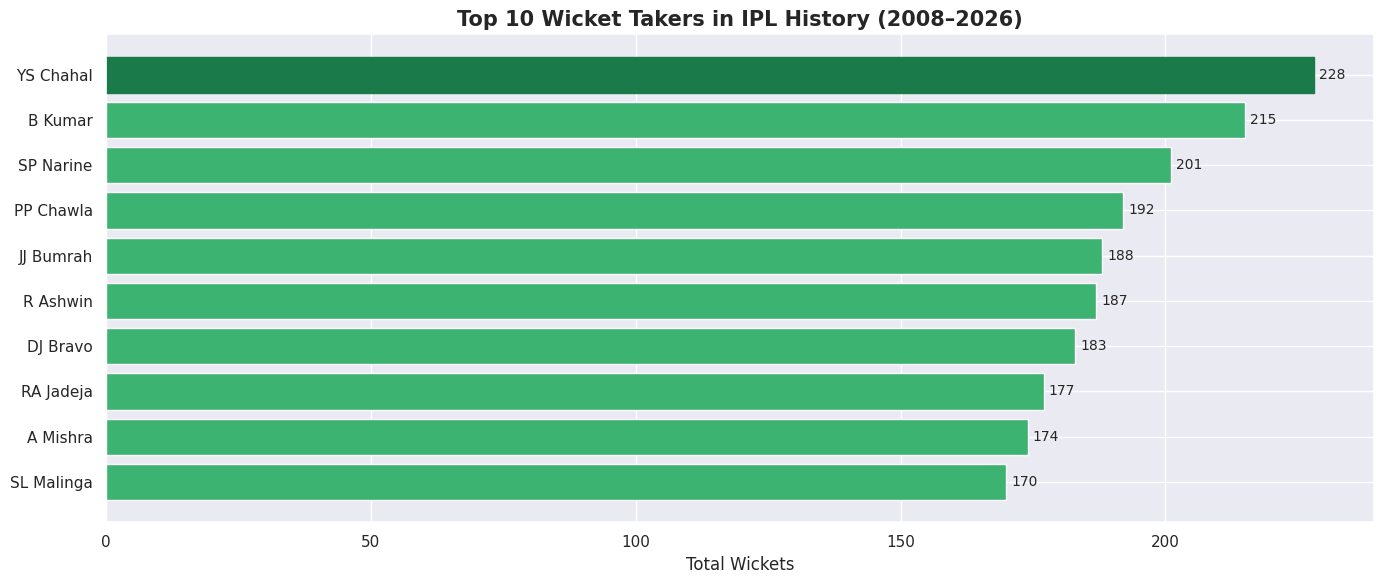


🎯 All-time top wicket taker: YS Chahal — 228 wickets


In [18]:
wickets = deliveries[
    (deliveries['is_wicket'] == True) &
    (~deliveries['wicket_kind'].isin(['run out','retired hurt','obstructing the field']))
]

top_bowlers = (wickets.groupby('bowler')['is_wicket']
               .count()
               .sort_values(ascending=False)
               .head(10))

plt.figure(figsize=(14,6))
bars = plt.barh(top_bowlers.index[::-1], top_bowlers.values[::-1],
                color='mediumseagreen', edgecolor='white')
bars[-1].set_color('#1a7a4a')

for bar in bars:
    plt.text(bar.get_width() + 1,
             bar.get_y() + bar.get_height()/2,
             str(int(bar.get_width())),
             va='center', fontsize=10)

plt.title('Top 10 Wicket Takers in IPL History (2008–2026)',
          fontsize=15, fontweight='bold')
plt.xlabel('Total Wickets')
plt.tight_layout()
plt.savefig('top_bowlers.png', dpi=150)
plt.show()

print(f"\n🎯 All-time top wicket taker: {top_bowlers.index[0]} — {top_bowlers.values[0]} wickets")

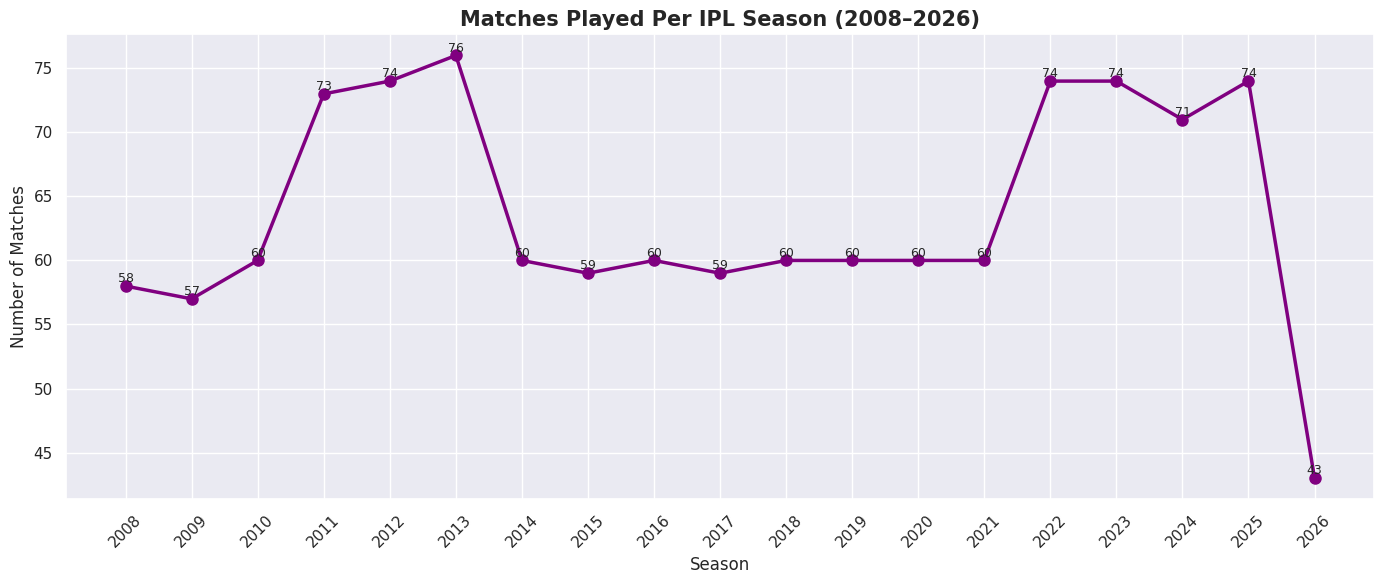


⚠️ Note: 2026 season shows fewer matches (43) because the dataset  
captures data only up to May 1, 2026. The full season was not 
yet complete at the time of data collection.



In [19]:
season_matches = (matches.groupby('season_id')
                  .size()
                  .reset_index(name='matches_played'))

plt.figure(figsize=(14,6))
plt.plot(season_matches['season_id'], season_matches['matches_played'],
         marker='o', color='purple', linewidth=2.5, markersize=8)

for _, row in season_matches.iterrows():
    plt.text(row['season_id'], row['matches_played'] + 0.3,
             str(row['matches_played']), ha='center', fontsize=9)

plt.title('Matches Played Per IPL Season (2008–2026)',
          fontsize=15, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(season_matches['season_id'], rotation=45)
plt.tight_layout()
plt.savefig('season_trend.png', dpi=150)
plt.show()

print("\n" + "="*70)
print("⚠️ Note: 2026 season shows fewer matches (43) because the dataset  ")
print("captures data only up to May 1, 2026. The full season was not ")
print("yet complete at the time of data collection.")
print("="*70 + "\n")

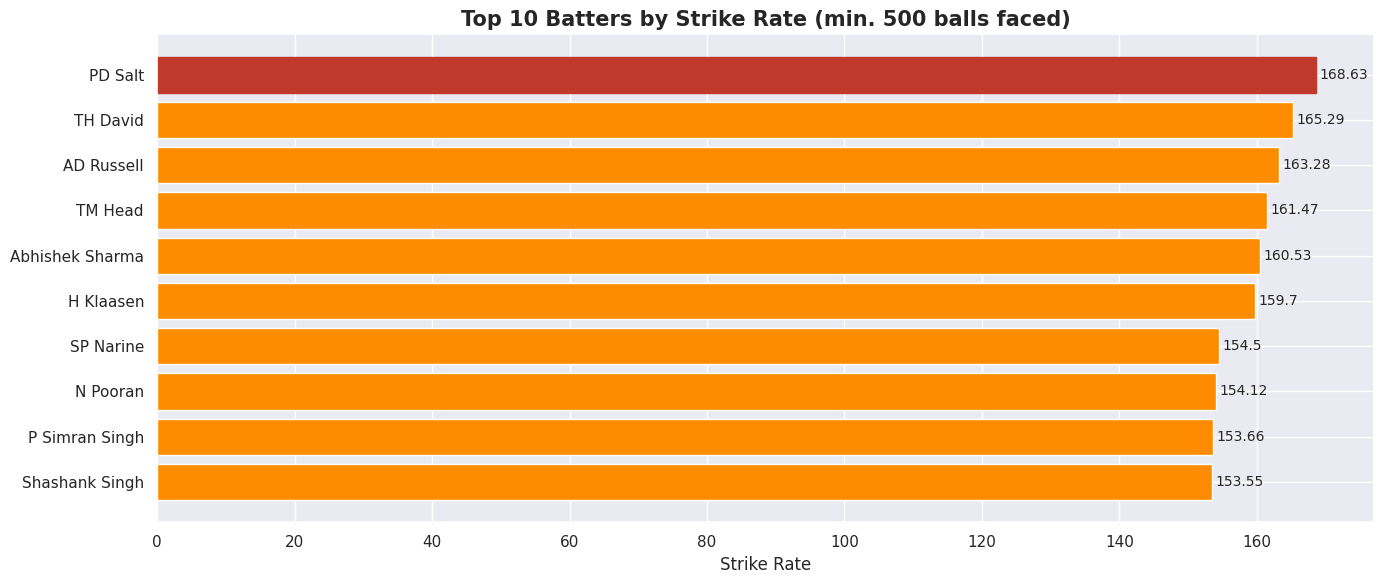


⚡ Highest strike rate:
              batter  total_runs  balls_faced  strike_rate
468          PD Salt        1258          746       168.63
662         TH David        1038          628       165.29
40        AD Russell        2655         1626       163.28
667          TM Head        1408          872       161.47
71   Abhishek Sharma        2241         1396       160.53


In [20]:
strike_rate = deliveries.groupby('batter').agg(
    total_runs=('batter_runs', 'sum'),
    balls_faced=('batter_runs', 'count')
).reset_index()

# Minimum 500 balls to filter out casual players
strike_rate = strike_rate[strike_rate['balls_faced'] >= 500]
strike_rate['strike_rate'] = (strike_rate['total_runs'] /
                               strike_rate['balls_faced'] * 100).round(2)
strike_rate = strike_rate.sort_values('strike_rate', ascending=False).head(10)

plt.figure(figsize=(14,6))
bars = plt.barh(strike_rate['batter'][::-1],
                strike_rate['strike_rate'][::-1],
                color='darkorange', edgecolor='white')
bars[-1].set_color('#c0392b')

for bar in bars:
    plt.text(bar.get_width() + 0.5,
             bar.get_y() + bar.get_height()/2,
             str(bar.get_width()),
             va='center', fontsize=10)

plt.title('Top 10 Batters by Strike Rate (min. 500 balls faced)',
          fontsize=15, fontweight='bold')
plt.xlabel('Strike Rate')
plt.tight_layout()
plt.savefig('strike_rate.png', dpi=150)
plt.show()

print("\n⚡ Highest strike rate:")
print(strike_rate[['batter','total_runs','balls_faced','strike_rate']].head(5))

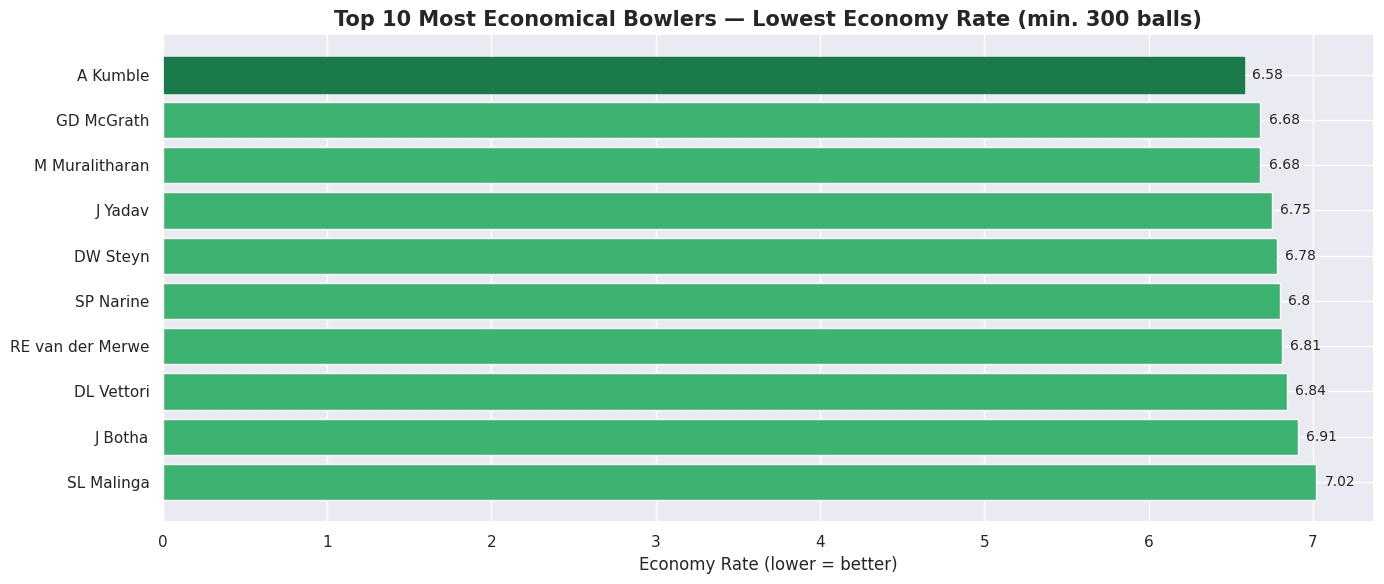


🎯 Most economical bowlers:
             bowler  runs_conceded  balls_bowled  economy
7          A Kumble           1063           970     6.58
160      GD McGrath            362           325     6.68
284  M Muralitharan           1703          1530     6.68
199         J Yadav            441           392     6.75
150        DW Steyn           2473          2189     6.78


In [21]:
economy = deliveries[deliveries['is_wide_ball'] == False].groupby('bowler').agg(
    runs_conceded=('total_runs', 'sum'),
    balls_bowled=('total_runs', 'count')
).reset_index()

# Minimum 300 balls to filter out occasional bowlers
economy = economy[economy['balls_bowled'] >= 300]
economy['economy'] = (economy['runs_conceded'] /
                       (economy['balls_bowled'] / 6)).round(2)
economy = economy.sort_values('economy').head(10)

plt.figure(figsize=(14,6))
bars = plt.barh(economy['bowler'][::-1],
                economy['economy'][::-1],
                color='mediumseagreen', edgecolor='white')
bars[-1].set_color('#1a7a4a')

for bar in bars:
    plt.text(bar.get_width() + 0.05,
             bar.get_y() + bar.get_height()/2,
             str(bar.get_width()),
             va='center', fontsize=10)

plt.title('Top 10 Most Economical Bowlers — Lowest Economy Rate (min. 300 balls)',
          fontsize=15, fontweight='bold')
plt.xlabel('Economy Rate (runs per over)')
plt.xlabel('Economy Rate (lower = better)')
plt.tight_layout()
plt.savefig('economy_rate.png', dpi=150)
plt.show()

print("\n🎯 Most economical bowlers:")
print(economy[['bowler','runs_conceded','balls_bowled','economy']].head(5))

In [22]:
print("\n" + "="*60)
print(" SQL QUERIES")
print("="*60 + "\n")


 SQL QUERIES



In [23]:
import sqlite3

conn = sqlite3.connect('ipl.db')
matches.to_sql('matches', conn, if_exists='replace', index=False)
deliveries.to_sql('deliveries', conn, if_exists='replace', index=False)

print("✅ SQLite database created!")
print("Tables: matches, deliveries")

✅ SQLite database created!
Tables: matches, deliveries


In [24]:
q1 = pd.read_sql_query("""
    SELECT match_winner_name, COUNT(*) AS total_wins
    FROM matches
    WHERE match_winner_name != 'No Result'
    GROUP BY match_winner_name
    ORDER BY total_wins DESC
""", conn)
print("Q1: Most Wins by Team")
print(q1)

Q1: Most Wins by Team
              match_winner_name  total_wins
0                Mumbai Indians         155
1           Chennai Super Kings         146
2   Royal Challengers Bengaluru         139
3         Kolkata Knight Riders         137
4           Sunrisers Hyderabad         132
5                  Punjab Kings         130
6                Delhi Capitals         126
7              Rajasthan Royals         125
8                Gujarat Titans          42
9          Lucknow Super Giants          33
10      Rising Pune Supergiants          15
11                Pune Warriors          13
12                Gujarat Lions          13
13         Kochi Tuskers Kerala           6


In [25]:
q2 = pd.read_sql_query("""
    SELECT
        SUM(CASE WHEN toss_winner_name = match_winner_name THEN 1 ELSE 0 END) AS toss_also_won,
        COUNT(*) AS total_matches,
        ROUND(100.0 * SUM(CASE WHEN toss_winner_name = match_winner_name THEN 1 ELSE 0 END)
              / COUNT(*), 2) AS toss_win_pct
    FROM matches
    WHERE match_winner_name != 'No Result'
""", conn)
print("Q2: Toss Impact")
print(q2)

Q2: Toss Impact
   toss_also_won  total_matches  toss_win_pct
0            626           1212         51.65


In [26]:
q3 = pd.read_sql_query("""
    SELECT toss_winner_name, toss_decision, COUNT(*) AS times
    FROM matches
    GROUP BY toss_winner_name, toss_decision
    ORDER BY toss_winner_name, times DESC
""", conn)
print("Q3: Toss Decision by Team")
print(q3)

Q3: Toss Decision by Team
               toss_winner_name toss_decision  times
0           Chennai Super Kings         field     70
1           Chennai Super Kings           bat     60
2                Delhi Capitals         field    102
3                Delhi Capitals           bat     43
4                 Gujarat Lions         field     14
5                 Gujarat Lions           bat      1
6                Gujarat Titans         field     27
7                Gujarat Titans           bat      6
8          Kochi Tuskers Kerala         field      5
9          Kochi Tuskers Kerala           bat      3
10        Kolkata Knight Riders         field     90
11        Kolkata Knight Riders           bat     42
12         Lucknow Super Giants         field     22
13         Lucknow Super Giants           bat      7
14               Mumbai Indians         field    101
15               Mumbai Indians           bat     55
16                Pune Warriors           bat     11
17                Pu

In [27]:
q4 = pd.read_sql_query("""
    SELECT batter, SUM(batter_runs) AS total_runs
    FROM deliveries
    GROUP BY batter
    ORDER BY total_runs DESC
    LIMIT 10
""", conn)
print("Q4: Top 10 Run Scorers")
print(q4)

Q4: Top 10 Run Scorers
           batter  total_runs
0         V Kohli        9050
1       RG Sharma        7185
2        S Dhawan        6769
3       DA Warner        6567
4        KL Rahul        5668
5        SK Raina        5536
6        MS Dhoni        5439
7       AM Rahane        5194
8  AB de Villiers        5181
9       SV Samson        5008


In [28]:
q5 = pd.read_sql_query("""
    SELECT bowler, COUNT(*) AS wickets
    FROM deliveries
    WHERE is_wicket = 1
    AND wicket_kind NOT IN ('run out','retired hurt','obstructing the field')
    GROUP BY bowler
    ORDER BY wickets DESC
    LIMIT 10
""", conn)
print("Q5: Top 10 Wicket Takers")
print(q5)

Q5: Top 10 Wicket Takers
       bowler  wickets
0   YS Chahal      228
1     B Kumar      215
2   SP Narine      201
3   PP Chawla      192
4   JJ Bumrah      188
5    R Ashwin      187
6    DJ Bravo      183
7   RA Jadeja      177
8    A Mishra      174
9  SL Malinga      170


In [29]:
q6 = pd.read_sql_query("""
    SELECT
        season_id,
        COUNT(*) AS total_matches,
        SUM(CASE WHEN toss_winner_name = match_winner_name THEN 1 ELSE 0 END) AS toss_wins,
        ROUND(100.0 * SUM(CASE WHEN toss_winner_name = match_winner_name THEN 1 ELSE 0 END)
              / COUNT(*), 2) AS toss_win_pct
    FROM matches
    WHERE match_winner_name != 'No Result'
    GROUP BY season_id
    ORDER BY season_id
""", conn)
print("Bonus: Season-wise Toss Win %")
print(q6)

Bonus: Season-wise Toss Win %
    season_id  total_matches  toss_wins  toss_win_pct
0        2008             58         28         48.28
1        2009             57         33         57.89
2        2010             60         31         51.67
3        2011             73         38         52.05
4        2012             74         33         44.59
5        2013             76         36         47.37
6        2014             60         30         50.00
7        2015             59         29         49.15
8        2016             60         34         56.67
9        2017             59         34         57.63
10       2018             60         32         53.33
11       2019             60         36         60.00
12       2020             60         28         46.67
13       2021             60         34         56.67
14       2022             74         36         48.65
15       2023             74         35         47.30
16       2024             71         31         43.6

In [30]:
print("=" * 60)
print("        IPL PERFORMANCE ANALYTICS — KEY INSIGHTS")
print("         2008 to 2026 | 1212 Matches | 19 Seasons")
print("=" * 60)

print("""
🏆 TEAM PERFORMANCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Mumbai Indians are the most successful IPL team with 155 wins
- Chennai Super Kings are close behind with 146 wins
- Top 4 teams (MI, CSK, RCB, KKR) account for 575 wins —
  nearly 47% of all matches played

🎲 TOSS ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Toss winners go on to win only 51.65% of matches
- Toss advantage is minimal — barely better than a coin flip
- 66% of teams choose to field after winning the toss
- Fielding first is the dominant strategy across all seasons

🏏 BATTING HIGHLIGHTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Virat Kohli is the all-time leading run scorer with 9,050 runs
- Kohli leads Rohit Sharma by nearly 2,000 runs
- PD Salt has the highest strike rate (168.63) among
  established batters (min. 500 balls)
- All top 10 strike rate batters scored above 150 —
  T20 cricket has become significantly more aggressive

🎯 BOWLING HIGHLIGHTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- YS Chahal leads all-time wickets with 228 dismissals
- Bhuvneshwar Kumar is the leading pace bowler with 215 wickets
- A Kumble holds the best economy rate at 6.58 runs per over
- Spinners dominate both wickets and economy — ideal for
  Indian conditions

📅 SEASON TRENDS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- IPL grew from 58 matches in 2008 to 74 in recent seasons
- 2026 shows 43 matches — dataset captured mid-season only
- 2025 had the highest toss-to-win conversion at 60.81%
- Tournament has stabilized at 74 matches with 10 teams
  since 2022
""")

print("=" * 60)
print("Analysis by: M Nisthula | Tools: Python, SQL, Power BI")
print("=" * 60)

        IPL PERFORMANCE ANALYTICS — KEY INSIGHTS
         2008 to 2026 | 1212 Matches | 19 Seasons

🏆 TEAM PERFORMANCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Mumbai Indians are the most successful IPL team with 155 wins
- Chennai Super Kings are close behind with 146 wins
- Top 4 teams (MI, CSK, RCB, KKR) account for 575 wins —
  nearly 47% of all matches played

🎲 TOSS ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Toss winners go on to win only 51.65% of matches
- Toss advantage is minimal — barely better than a coin flip
- 66% of teams choose to field after winning the toss
- Fielding first is the dominant strategy across all seasons

🏏 BATTING HIGHLIGHTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Virat Kohli is the all-time leading run scorer with 9,050 runs
- Kohli leads Rohit Sharma by nearly 2,000 runs
- PD Salt has the highest strike rate (168.63) among
  established batters (min. 500 balls)
- All top 10 strike r

In [31]:
import os
os.makedirs('ipl_exports', exist_ok=True)

# Export cleaned files
matches.to_csv('ipl_exports/matches_clean.csv', index=False)
deliveries.to_csv('ipl_exports/deliveries_clean.csv', index=False)

# Export SQL query results
q1.to_csv('ipl_exports/team_wins.csv', index=False)
q4.to_csv('ipl_exports/top_batters.csv', index=False)
q5.to_csv('ipl_exports/top_bowlers.csv', index=False)
q6.to_csv('ipl_exports/season_toss.csv', index=False)

print("✅ All files exported to ipl_exports/ folder!")
print("\nFiles ready for Power BI:")
for f in os.listdir('ipl_exports'):
    print(f"  → {f}")

✅ All files exported to ipl_exports/ folder!

Files ready for Power BI:
  → deliveries_clean.csv
  → top_batters.csv
  → team_wins.csv
  → season_toss.csv
  → matches_clean.csv
  → top_bowlers.csv


In [32]:
import os
from google.colab import files

for f in os.listdir('ipl_exports'):
    files.download(f'ipl_exports/{f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
# Already sorted top 10 — export again
top_batters_sorted = deliveries.groupby('batter')['batter_runs']\
    .sum().sort_values(ascending=False).head(10).reset_index()
top_batters_sorted.columns = ['batter', 'total_runs']

top_bowlers_sorted = deliveries[
    (deliveries['is_wicket'] == True) &
    (~deliveries['wicket_kind'].isin(['run out','retired hurt','obstructing the field']))
].groupby('bowler')['is_wicket'].count()\
    .sort_values(ascending=False).head(10).reset_index()
top_bowlers_sorted.columns = ['bowler', 'wickets']

top_batters_sorted.to_csv('top_batters_final.csv', index=False)
top_bowlers_sorted.to_csv('top_bowlers_final.csv', index=False)

print(top_batters_sorted)
print(top_bowlers_sorted)

           batter  total_runs
0         V Kohli        9050
1       RG Sharma        7185
2        S Dhawan        6769
3       DA Warner        6567
4        KL Rahul        5668
5        SK Raina        5536
6        MS Dhoni        5439
7       AM Rahane        5194
8  AB de Villiers        5181
9       SV Samson        5008
       bowler  wickets
0   YS Chahal      228
1     B Kumar      215
2   SP Narine      201
3   PP Chawla      192
4   JJ Bumrah      188
5    R Ashwin      187
6    DJ Bravo      183
7   RA Jadeja      177
8    A Mishra      174
9  SL Malinga      170


In [34]:
from google.colab import files
files.download('top_batters_final.csv')
files.download('top_bowlers_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
print("Total deliveries:", len(deliveries))
print("Seasons covered:", deliveries['season_id'].unique())
print("Kohli total runs:", deliveries[deliveries['batter']=='V Kohli']['batter_runs'].sum())

Total deliveries: 288226
Seasons covered: [2008 2017 2018 2019 2020 2021 2022 2023 2024 2025 2012 2009 2010 2011
 2015 2013 2014 2016 2026]
Kohli total runs: 9050


In [36]:
from google.colab import files
top_batters_sorted.to_csv('top_batters_final.csv', index=False)
top_bowlers_sorted.to_csv('top_bowlers_final.csv', index=False)
files.download('top_batters_final.csv')
files.download('top_bowlers_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>